# DBSCAN Traffic Hotspot Detection
Unsupervised AI for Bangalore traffic

In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


In [14]:

# Load dataset
df = pd.read_csv("../data/Banglore_traffic_Dataset.csv")

# Basic preprocessing
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['hour'] = df['Date'].dt.hour

df['Traffic Volume'] = pd.to_numeric(df['Traffic Volume'], errors='coerce')
df['Congestion Level'] = pd.to_numeric(df['Congestion Level'], errors='coerce')

df = df.dropna(subset=['Traffic Volume', 'Congestion Level', 'hour'])
df.head()


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity,hour
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No,0
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No,0
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No,0
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No,0
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No,0


In [15]:

# Area to Latitude & Longitude mapping
area_coords = {
    "Indiranagar": (12.9719, 77.6412),
    "Whitefield": (12.9698, 77.7500),
    "Koramangala": (12.9352, 77.6245),
    "Electronic City": (12.8452, 77.6600),
    "Hebbal": (13.0358, 77.5970),
    "MG Road": (12.9758, 77.6096),
    "Yeshwanthpur": (13.0285, 77.5400),
    "Jayanagar": (12.9250, 77.5938),
    "Marathahalli": (12.9591, 77.6974)
}

df['lat'] = df['Area Name'].map(lambda x: area_coords.get(x, (np.nan, np.nan))[0])
df['lon'] = df['Area Name'].map(lambda x: area_coords.get(x, (np.nan, np.nan))[1])

df = df.dropna(subset=['lat','lon'])
df.head()


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity,hour,lat,lon
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No,0,12.9719,77.6412
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No,0,12.9719,77.6412
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No,0,12.9698,77.7500
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No,0,12.9352,77.6245
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No,0,12.9352,77.6245


In [16]:

# Feature selection for DBSCAN
X = df[['lat', 'lon', 'Traffic Volume', 'Congestion Level']]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [17]:

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.6, min_samples=30)
df['hotspot_cluster'] = dbscan.fit_predict(X_scaled)

df['hotspot_cluster'].value_counts()


hotspot_cluster
2    2537
0    1720
3     950
1     942
4     734
5     552
Name: count, dtype: int64

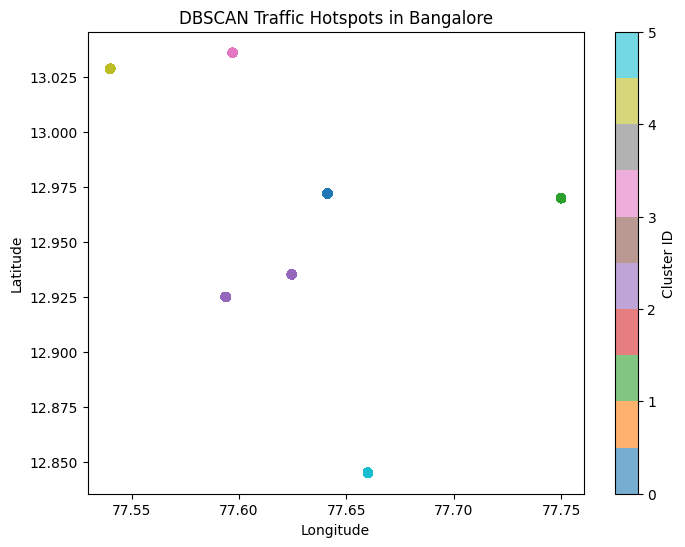

In [18]:

# Visualize traffic hotspots
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    df['lon'],
    df['lat'],
    c=df['hotspot_cluster'],
    cmap='tab10',
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Traffic Hotspots in Bangalore")
plt.colorbar(scatter, label="Cluster ID")
plt.show()



In [ ]:
import os

os.makedirs("../backend/data", exist_ok=True)

hotspots = df[df['hotspot_cluster'] != -1][
    ['Area Name', 'lat', 'lon', 'Traffic Volume', 'Congestion Level', 'hotspot_cluster']
]

hotspots.to_csv("../backend/data/hotspots.csv", index=False)


: 


### Interpretation
- Cluster `-1` → Non-hotspot / noise  
- Cluster `0,1,2...` → Traffic congestion hotspots  

This completes unsupervised hotspot detection using DBSCAN.
